<a href="https://colab.research.google.com/github/ankan-git-coder/SUPERVISED-MACHINE-LEARNING/blob/main/fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("amanalisiddiqui/fraud-detection-dataset")

print("Path to dataset files:", path)

100%|██████████| 178M/178M [00:01<00:00, 154MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/amanalisiddiqui/fraud-detection-dataset/versions/1


In [5]:
import os

print(os.listdir(path))

['AIML Dataset.csv']


In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [7]:


df = pd.read_csv(path + "/AIML Dataset.csv")

In [8]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [9]:
df.shape

(6362620, 11)

In [10]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [12]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


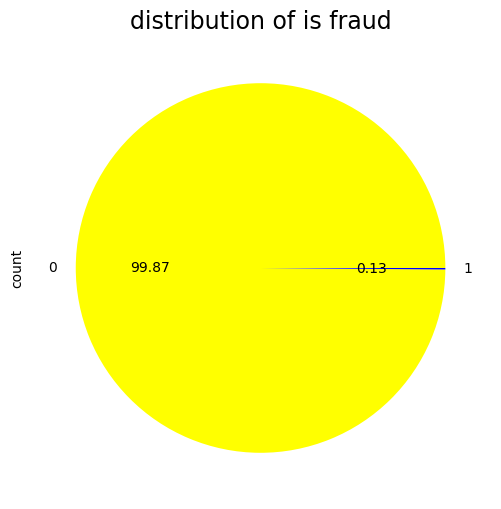

In [13]:
df['isFraud'].value_counts().plot(kind='pie',autopct='%.2f', figsize=(12,6), colors=['yellow', 'blue'])
plt.title('distribution of is fraud', fontsize=17)
plt.show()

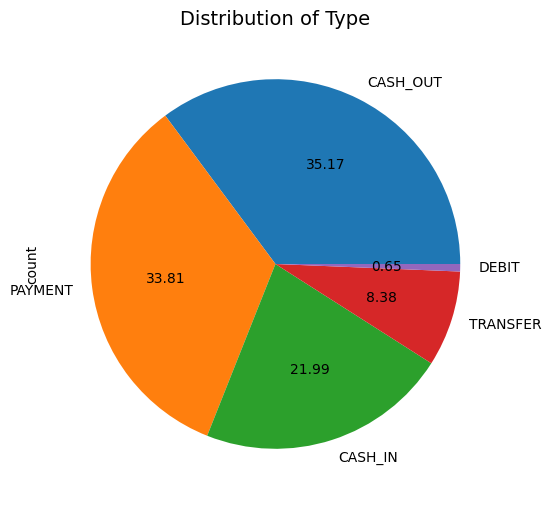

In [14]:
df['type'].value_counts().plot(kind='pie', autopct='%.2f', figsize=(12,6))
plt.title('Distribution of Type', fontsize=14)
plt.show()

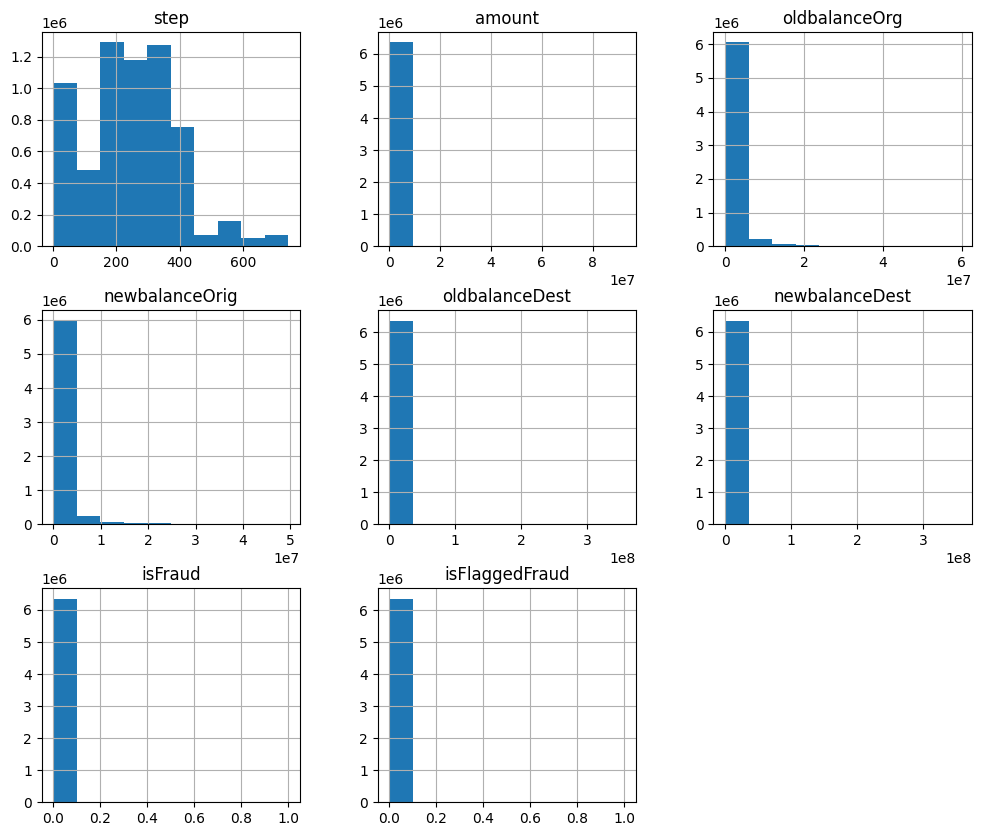

In [15]:
df.hist(figsize=(12,10))
plt.show()

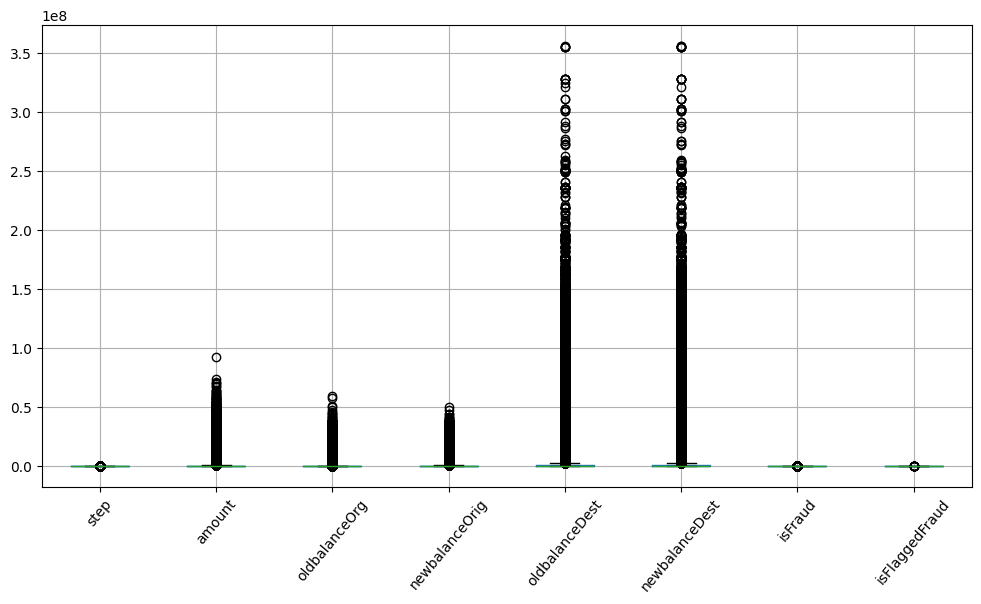

In [16]:

df.boxplot(figsize=(12,6))
plt.xticks(rotation=50)
plt.show()

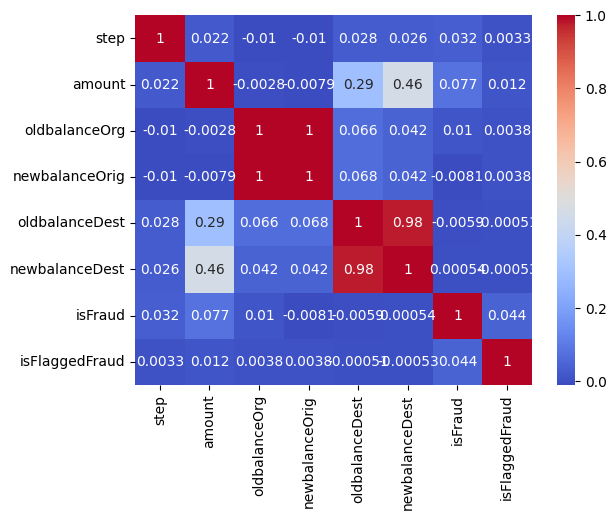

In [17]:
figsize=(9,6)
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score , precision_score, recall_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

In [19]:
df.drop(columns=['nameOrig', 'nameDest'], inplace=True, axis =1)

In [20]:
df.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,0
1,1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,0
2,1,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,0
3,1,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,0


In [21]:
le = LabelEncoder()
df['type']  = le.fit_transform(df['type'])



In [26]:
X = df.drop(columns=['isFraud'])
y = df['isFraud']
X_train,X_test, y_train,y_test = train_test_split(X,y , test_size=0.3, random_state=42)

In [27]:

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(4453834, 8)
(4453834,)
(1908786, 8)
(1908786,)


In [29]:
model = RandomForestClassifier(
    n_estimators=20,   # number of trees
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=20, random_state=42)

In [30]:
y_test= model.predict(X_test)

In [33]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


print("RECALL SCORE:\n", recall_score(y_test, y_pred))


print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9986153502802305
Confusion Matrix:
 [[1906143     703]
 [   1940       0]]
RECALL SCORE:
 0.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906846
           1       0.00      0.00      0.00      1940

    accuracy                           1.00   1908786
   macro avg       0.50      0.50      0.50   1908786
weighted avg       1.00      1.00      1.00   1908786



In [35]:
df.columns

Index(['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
       'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud'],
      dtype='object')